In [1]:
"""
Implement FEMA model to train on the stocks to get a finger print of each 
then use some kind of temporal model (SARIMA, ARIMA, exponential smoothing, triple exponential smoothing (seasonal & yearly)) to predict the FEMA value for next month
Train a model (example can be LSTM) to predict the "unpredicatble" movement of the stock (what isnt obtained in the FEMA data/signal)

"""

'\nImplement FEMA model to train on the stocks to get a finger print of each \nthen use some kind of temporal model (SARIMA, ARIMA, exponential smoothing, triple exponential smoothing (seasonal & yearly)) to predict the FEMA value for next month\nTrain a model (example can be LSTM) to predict the "unpredicatble" movement of the stock (what isnt obtained in the FEMA data/signal)\n\n'

In [2]:
import pandas as pd
import numpy as np
import matplotlib as plt
import pandas_datareader.data as web
from datetime import date, timedelta
import statsmodels.api as sm
import torch 
import torch.nn as nn
import matplotlib.pyplot as plt

In [3]:
# Fema 
lookback_windows = [30, 60, 90, 180, 365]

# LSTM
lookback_windows_lstm = [30, 60, 90, 180, 365]
hidden_dims = [32, 64, 128, 256, 512]
input_dim = 10
hidden_dim = 10
num_layers = 1

In [4]:
# Import relevant data
trading_1min = pd.read_csv("data/yfinance/1m_interval_trading_data.csv")
trading_2min = pd.read_csv("data/yfinance/2m_interval_trading_data.csv")
trading_1h = pd.read_csv("data/yfinance/1h_interval_trading_data.csv")

background_data = pd.read_csv("data/yfinance/ticker_background_data_df.csv")

# Daily Fama-French 5 Factors
start = "2020-01-01"
end = date.today()

ff5 = web.DataReader("F-F_Research_Data_5_Factors_2x3_daily", "famafrench", start, end)

# ff5 is a dict-like object; the actual data is in ff5[0]
factors = ff5[0]
print(factors.tail())

/var/folders/vl/1jjwbkdj1r126_dp4xttqycm0000gn/T/ipykernel_17027/49755974.py:12: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff5 = web.DataReader("F-F_Research_Data_5_Factors_2x3_daily", "famafrench", start, end)


            Mkt-RF   SMB   HML   RMW   CMA    RF
Date                                            
2026-06-24   -0.07  0.78 -0.21  0.42  0.61  0.01
2026-06-25   -0.13  0.61  0.91 -0.76  0.51  0.01
2026-06-26    0.15  1.36 -0.95  0.44  0.04  0.01
2026-06-29    1.20 -0.89 -0.90 -1.77 -0.50  0.01
2026-06-30    0.73 -0.10 -0.62 -1.10 -0.49  0.01


In [5]:
dfs = {
    "1min": trading_1min,
    "2min": trading_2min,
    "1h": trading_1h,
}

for name, df in dfs.items():
    #Convert to EST
    df['Datetime'] = pd.to_datetime(df['Datetime'], utc=True).dt.tz_convert('America/New_York')
    df['Date'] = df['Datetime'].dt.normalize()

    # Obtain the close value at the end of each day only 
    df.sort_values(['Ticker', 'Datetime'], inplace=True)
    daily_close = df.groupby(['Ticker', 'Date'])['Close'].last().reset_index()

    daily_close = daily_close.sort_values(['Ticker', 'Date'])

    # Obtain Daily return 
    daily_close['Daily_Return'] = daily_close.groupby('Ticker')['Close'].pct_change() 

    # Add Daily features back to the original data
    merged = df.merge(daily_close[['Ticker', 'Date', 'Daily_Return']], on=['Ticker', 'Date'], how='inner')

    # Both datasets are in EST, but strip it from base 
    merged['Date'] = merged['Date'].dt.tz_localize(None)
    merged = merged.merge(factors, left_on = 'Date', right_index=True, how='left')

    # Calculate the Daily Excess Return (Daily Return - Risk Free Return)
    merged['Daily_Return'] = merged['Daily_Return'] * 100 # Convert to percent to match Risk Free value
    merged['Daily_Excess_Return'] = merged['Daily_Return'] - merged['RF']

    dfs[name] = merged  # store the result back in the dict

dfs['1h'][dfs['1h']['Ticker'] == 'AAPL'][['Date', 'Ticker', 'Daily_Return', 'Daily_Excess_Return']].drop_duplicates().head(10)

,Date,Ticker,Daily_Return,Daily_Excess_Return
0,2024-08-02,AAPL,NaN,NaN
7,2024-08-05,AAPL,-4.827116,-4.847116
14,2024-08-06,AAPL,-0.987142,-1.007142
21,2024-08-07,AAPL,1.320459,1.300459
28,2024-08-08,AAPL,1.658246,1.638246
35,2024-08-09,AAPL,1.387460,1.367460
42,2024-08-12,AAPL,0.577901,0.557901
49,2024-08-13,AAPL,1.709952,1.689952
56,2024-08-14,AAPL,0.158174,0.138174
63,2024-08-15,AAPL,1.394284,1.374284


### Obtain the optimal lookback window

In [6]:
### LOOK INTO VECTORIZING THIS AND MAKING IT SO I CAN TRAIN MULTIPLE FAMA MODELS WITH MULTIPLE TIME SLICES 
fama_outputs = {}
input_df = dfs['1h']
subset_x = ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']

# Set to 7 as we would be refitting this every day and to obtain new Fama values 
# could take MAX 7 days at a quant firm, so we would go max 7 days without re-fitting
def evaluate_window(ticker_data, train_window, test_window=7, step=None):
    if step == None:
        step = test_window
    
    fold_results = []

    for start in range(0, len(ticker_data) - train_window - test_window + 1, step):

        # Obtain Train & Test Window Data
        train_data = ticker_data.iloc[start : start + train_window]
        test_data = ticker_data.iloc[start + train_window : start + train_window + test_window]

        # Fit OLS model and test 
        if not train_data.empty and not test_data.empty:

            # Fit on training Data
            X_train = sm.add_constant(train_data[subset_x], has_constant='add')
            y_train = train_data['Daily_Excess_Return']
            
            fama_5_factor_model = sm.OLS(y_train, X_train).fit(cov_type='HAC', cov_kwds={'maxlags': 5}) #LOOK INTO OBTAINING AN OPTIMAL VALUE 
            pred_train = fama_5_factor_model.predict(X_train)

            sse_train = ((y_train - pred_train) ** 2).sum()
            sst_train = ((y_train - y_train.mean()) ** 2).sum()
            r2_train = 1 - sse_train / sst_train if sst_train > 0 else float('nan')
            mse_train = sse_train / len(y_train)
            rmse_train = mse_train ** 0.5
            
            # Input testing data
            X_test = sm.add_constant(test_data[subset_x], has_constant='add')
            y_test = test_data['Daily_Excess_Return']
            pred_test = fama_5_factor_model.predict(X_test)

            sse_test = ((y_test - pred_test) ** 2).sum()
            sst_test = ((y_test - y_test.mean()) ** 2).sum()
            r2_test = 1 - sse_test / sst_test if sst_test > 0 else float('nan')
            mse_test = sse_test / len(y_test)
            rmse_test = mse_test ** 0.5

            fold_results.append({
                "Window_Start": train_data['Date'].iloc[0],
                "Window_End": train_data['Date'].iloc[-1],
                "Test_Start": test_data['Date'].iloc[0],
                "Test_End": test_data['Date'].iloc[-1],
                "N_Train": len(y_train),
                "N_Test": len(y_test),
                "SSE_Train": sse_train,
                "SST_Train": sst_train,
                "R2_Train": r2_train,
                "MSE_Train": mse_train,
                "RMSE_Train": rmse_train,
                "SSE_Test": sse_test,
                "SST_Test": sst_test,
                "R2_Test": r2_test,
                "MSE_Test": mse_test,
                "RMSE_Test": rmse_test,
            })

        else:
            print(f"[SKIP] fold starting at index {start}: empty train or test window")

    if len(fold_results) == 0:
        return None

    return pd.DataFrame(fold_results)

for ticker in dfs['1h']['Ticker'].unique():

    # Fit on multiple lookback windows to determine the best one 
    for lookback in lookback_windows:
        fama_ticker_input = input_df[input_df['Ticker'] == ticker]
    
        fama_ticker_input = fama_ticker_input.dropna(subset=subset_x) # Filter out for data we have FAMA on
        fama_ticker_input = fama_ticker_input[fama_ticker_input['Date'] != fama_ticker_input['Date'].min()] #Filter out the first date (no returns)

        fama_ticker_input = fama_ticker_input[['Date', 'Ticker', 'Daily_Excess_Return', 'Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']].drop_duplicates()
        fama_ticker_input = fama_ticker_input.sort_values(['Date'])

        result = evaluate_window(fama_ticker_input, train_window=lookback)
        if result is not None:
            fama_outputs[(ticker, lookback)] = result
        else:
            print(f"[SKIP] {ticker}, lookback={lookback}: not enough data for any fold")

=== Summary statistics by lookback window ===

--- RMSE_Train ---
            mean  median     std     min     max  count
Lookback                                               
30        1.0754  0.9997  0.7177  0.0356  5.4491   1575
60        1.1755  1.1394  0.7390  0.0476  4.5200   1475
90        1.2169  1.1788  0.7528  0.0537  4.1439   1371
180       1.2633  1.2279  0.7661  0.0580  3.3828   1046
365       1.3056  1.2874  0.7572  0.0689  3.0935    396

--- RMSE_Test ---
            mean  median     std     min     max  count
Lookback                                               
30        1.3385  1.1700  1.0407  0.0180  8.6151   1575
60        1.2833  1.1109  1.0058  0.0228  9.1257   1475
90        1.2720  1.1152  0.9904  0.0285  8.9494   1371
180       1.2424  1.1176  0.9401  0.0244  9.0606   1046
365       1.3867  1.2993  0.9458  0.0376  7.7014    396

--- R2_Train ---
            mean  median     std     min     max  count
Lookback                                               
3

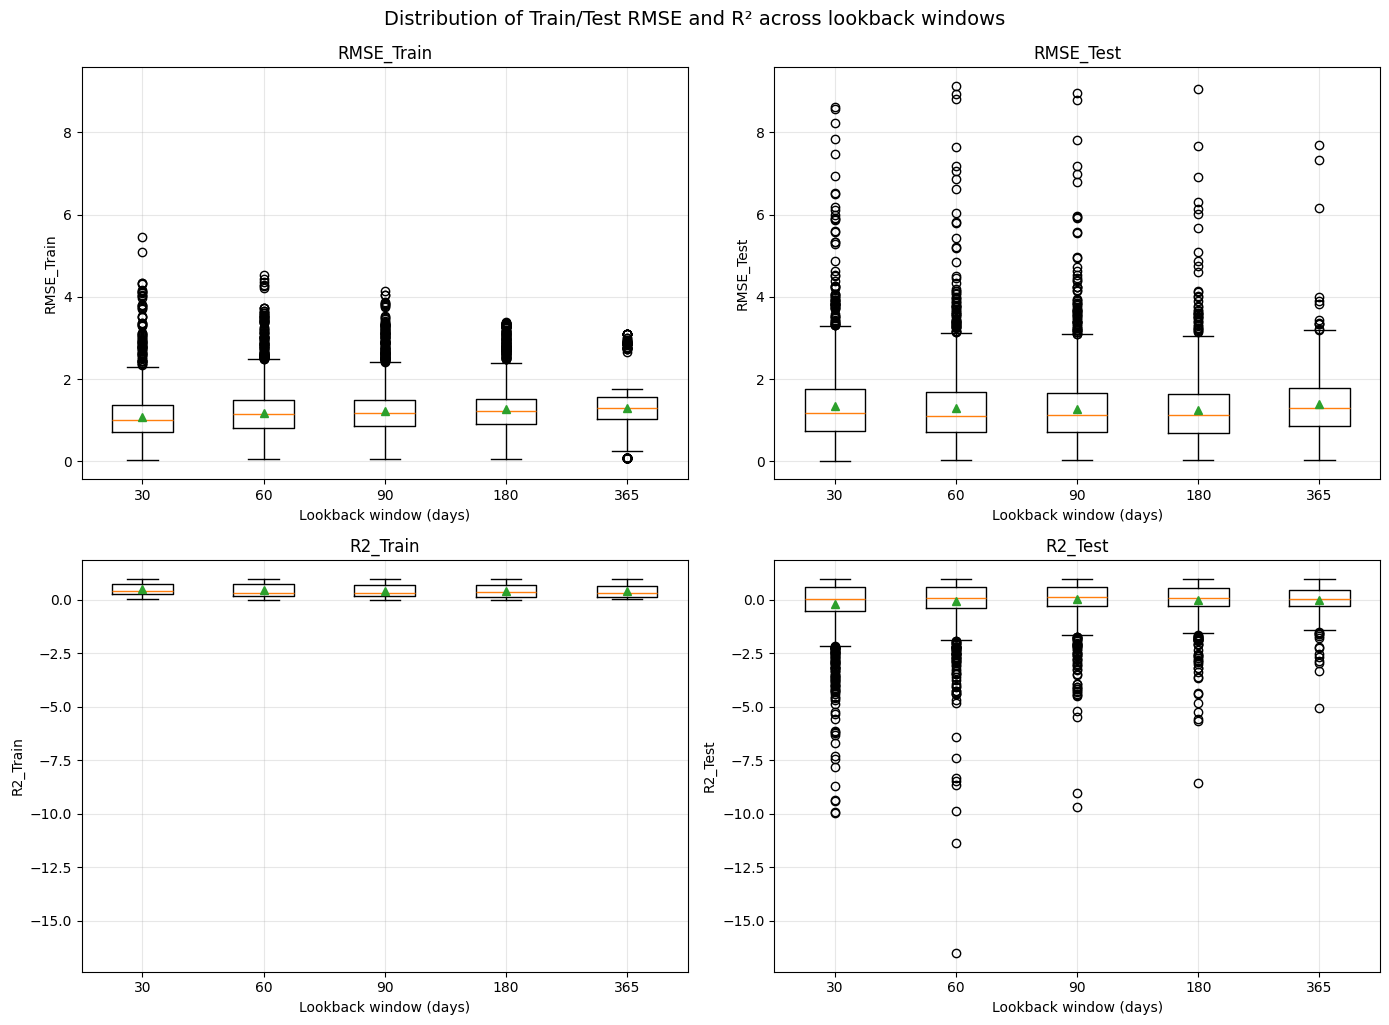

In [7]:
# Combine all fold-level results across every (ticker, lookback) into one 
all_folds = []
for (ticker, lookback), fold_df in fama_outputs.items():
    tmp = fold_df.copy()
    tmp["Ticker"] = ticker
    tmp["Lookback"] = lookback
    all_folds.append(tmp)

all_folds_df = pd.concat(all_folds, ignore_index=True)

metrics = ["RMSE_Train", "RMSE_Test", "R2_Train", "R2_Test"]

# Summary stats table per lookback window
summary = (
    all_folds_df
    .groupby("Lookback")[metrics]
    .agg(["mean", "median", "std", "min", "max", "count"])
    .round(4)
)

print("=== Summary statistics by lookback window ===")
for metric in metrics:
    print(f"\n--- {metric} ---")
    print(summary[metric])

# Distribution plots
lookback_windows_present = sorted(all_folds_df["Lookback"].unique())

# Shared y-axis ranges: one for the RMSE pair, one for the R2 pair
rmse_min = all_folds_df[["RMSE_Train", "RMSE_Test"]].min().min()
rmse_max = all_folds_df[["RMSE_Train", "RMSE_Test"]].max().max()
rmse_pad = (rmse_max - rmse_min) * 0.05

r2_min = all_folds_df[["R2_Train", "R2_Test"]].min().min()
r2_max = all_folds_df[["R2_Train", "R2_Test"]].max().max()
r2_pad = (r2_max - r2_min) * 0.05

y_ranges = {
    "RMSE_Train": (rmse_min - rmse_pad, rmse_max + rmse_pad),
    "RMSE_Test":  (rmse_min - rmse_pad, rmse_max + rmse_pad),
    "R2_Train":   (r2_min - r2_pad, r2_max + r2_pad),
    "R2_Test":    (r2_min - r2_pad, r2_max + r2_pad),
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, metric in zip(axes, metrics):
    data_by_window = [
        all_folds_df.loc[all_folds_df["Lookback"] == lb, metric].dropna()
        for lb in lookback_windows_present
    ]
    ax.boxplot(data_by_window, tick_labels=lookback_windows_present, showmeans=True)
    ax.set_title(metric)
    ax.set_xlabel("Lookback window (days)")
    ax.set_ylabel(metric)
    ax.grid(alpha=0.3)
    ax.set_ylim(y_ranges[metric])

plt.tight_layout()
plt.suptitle("Distribution of Train/Test RMSE and R² across lookback windows", y=1.02, fontsize=14)
plt.show()

Results show that to maximize R2 and to minimize RMSE on the test set, we should pick a lookback window of 90. 

### Identify the best hyperparemeters for the LSTM

In [ ]:
# Obtain residuals to feed into LSTM
subset_x = ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']

def get_residual_series(ticker_data, fama_lookback=90):
    """Fit rolling Fama-French models and return the residual for each day (out-of-sample, one-step)."""
    ticker_data = ticker_data.sort_values('Date').reset_index(drop=True)
    
    residuals = []

    for i in range(fama_lookback, len(ticker_data)):
        train = ticker_data.iloc[i - fama_lookback : i]
        current = ticker_data.iloc[[i]]  # single row, the day we're predicting

        X_train = sm.add_constant(train[subset_x], has_constant='add')
        y_train = train['Daily_Excess_Return']
        model = sm.OLS(y_train, X_train).fit()

        X_current = sm.add_constant(current[subset_x], has_constant='add')
        pred = model.predict(X_current).values[0]
        actual = current['Daily_Excess_Return'].values[0]

        residuals.append({
            "Date": current['Date'].values[0],
            "Residual": actual - pred,
        })

    return pd.DataFrame(residuals)

def make_sequences(residual_series, lookback):
    """Turn a 1D residual series into (X, y) sequence pairs."""
    X, y = [], []
    for i in range(lookback, len(residual_series)):
        X.append(residual_series[i - lookback : i])
        y.append(residual_series[i])

    return np.array(X), np.array(y)

class ResidualLSTM(nn.Module):
    def __init__(self, hidden_dim, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # x shape: (batch, seq_len, 1)
        out, _ = self.lstm(x)
        last_hidden = out[:, -1, :]  # take the last time step's output
        return self.fc(last_hidden).squeeze(-1)

def train_and_evaluate(residual_series, lookback, hidden_dim, test_frac=0.2, epochs=50, lr=0.001):
    X, y = make_sequences(residual_series, lookback)
    if len(X) < 20:  # not enough data for this lookback size
        return None

    split = int(len(X) * (1 - test_frac))
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    if len(X_test) == 0 or len(X_train) == 0:
        return None

    # Standardize using train stats only (avoid leakage)
    mean, std = X_train.mean(), X_train.std() + 1e-8
    X_train_t = torch.tensor((X_train - mean) / std, dtype=torch.float32).unsqueeze(-1)
    X_test_t  = torch.tensor((X_test - mean) / std, dtype=torch.float32).unsqueeze(-1)
    y_train_t = torch.tensor((y_train - mean) / std, dtype=torch.float32)
    y_test_t  = torch.tensor((y_test - mean) / std, dtype=torch.float32)

    model = ResidualLSTM(hidden_dim=hidden_dim)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    model.train()
    for epoch in range(epochs):
        optimizer.zero_grad()
        pred = model(X_train_t)
        loss = loss_fn(pred, y_train_t)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        pred_train = model(X_train_t)
        pred_test = model(X_test_t)

        mse_train = loss_fn(pred_train, y_train_t).item()
        mse_test = loss_fn(pred_test, y_test_t).item()

        # R2, computed in original (unstandardized) scale for interpretability
        pred_test_orig = pred_test.numpy() * std + mean
        y_test_orig = y_test
        sse = ((y_test_orig - pred_test_orig) ** 2).sum()
        sst = ((y_test_orig - y_test_orig.mean()) ** 2).sum()
        r2_test = 1 - sse / sst if sst > 0 else float('nan')

    return {
        "Lookback": lookback,
        "Hidden_Dim": hidden_dim,
        "MSE_Train": mse_train,
        "MSE_Test": mse_test,
        "RMSE_Train": mse_train ** 0.5,
        "RMSE_Test": mse_test ** 0.5,
        "R2_Test": r2_test,
        "N_Train": len(X_train),
        "N_Test": len(X_test),
    }

In [11]:
lstm_lookback_windows = [10, 20, 30, 60, 90, 180, 365]
hidden_dims = [8, 16, 32, 64, 128]

lstm_outputs = {}

for ticker in dfs['1h']['Ticker'].unique():
    ticker_data = dfs['1h'][dfs['1h']['Ticker'] == ticker]
    ticker_data = ticker_data.dropna(subset=subset_x)
    ticker_data = ticker_data[['Date', 'Daily_Excess_Return'] + subset_x].drop_duplicates().sort_values('Date')

    residual_df = get_residual_series(ticker_data, fama_lookback=90)
    if residual_df.empty:
        print(f"[SKIP] {ticker}: not enough data for residuals")
        continue

    residual_series = residual_df['Residual'].values

    for lb in lstm_lookback_windows:
        for hd in hidden_dims:
            result = train_and_evaluate(residual_series, lookback=lb, hidden_dim=hd)
            if result is not None:
                result["Ticker"] = ticker
                lstm_outputs[(ticker, lb, hd)] = result
            else:
                print(f"[SKIP] {ticker}, lookback={lb}, hidden_dim={hd}: not enough data")

lstm_results_df = pd.DataFrame(lstm_outputs.values())

summary = (
    lstm_results_df
    .groupby(["Ticker", "Lookback", "Hidden_Dim"])[["RMSE_Train", "RMSE_Test", "R2_Test"]]
    .agg(["mean", "median", "std", "count"])
    .round(4)
)
print(summary)

KeyboardInterrupt: 

# BELOW IS AI CHECK TO SEE IF IT MAKE SENSE

In [8]:
# Obtain residuals to feed into LSTM
subset_x = ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']

def get_residual_series(ticker_data, fama_lookback=90, factor_forecast_span=10):
    """
    Fit rolling Fama-French models and calculate one-step-ahead residuals.

    For day t:
      1. Estimate FF coefficients using days t-fama_lookback through t-1.
      2. Forecast each FF factor for t using an EWMA through t-1.
      3. Predict the FF component of return_t using those forecast factors.
      4. Calculate residual_t = actual return_t - predicted FF return_t.
    """
    ticker_data = ticker_data.sort_values('Date').reset_index(drop=True)
    residuals = []

    for i in range(fama_lookback, len(ticker_data)):
        train = ticker_data.iloc[i - fama_lookback:i]
        current = ticker_data.iloc[[i]]

        # Fit FF model using ONLY information available before day t
        X_train = sm.add_constant(train[subset_x], has_constant='add')
        y_train = train['Daily_Excess_Return']
        model = sm.OLS(y_train, X_train).fit()

        # Forecast day-t factors using ONLY factors through day t-1
        prior_factors = ticker_data.iloc[:i][subset_x]
        forecast_factors = (
            prior_factors
            .ewm(span=factor_forecast_span, adjust=False)
            .mean()
            .iloc[-1]
        )

        # Predict day-t return using forecasted day-t factors
        X_forecast = pd.DataFrame(
            [forecast_factors],
            columns=subset_x
        )
        X_forecast = sm.add_constant(X_forecast, has_constant='add')

        pred = model.predict(X_forecast).values[0]
        actual = current['Daily_Excess_Return'].values[0]

        residuals.append({
            "Date": current['Date'].values[0],
            "Residual": actual - pred,

            # Forecast of today's factors, made using information through yesterday
            "Forecast_Mkt-RF": forecast_factors['Mkt-RF'],
            "Forecast_SMB": forecast_factors['SMB'],
            "Forecast_HML": forecast_factors['HML'],
            "Forecast_RMW": forecast_factors['RMW'],
            "Forecast_CMA": forecast_factors['CMA']
        })

    return pd.DataFrame(residuals)

def make_sequences_multivariate(model_input, feature_cols, target_col, lookback):
    """Create multivariate LSTM sequences."""
    X, y = [], []
    values = model_input[feature_cols].values.astype(float)
    targets = model_input[target_col].values.astype(float)

    for i in range(lookback, len(model_input)):
        X.append(values[i - lookback:i])
        y.append(targets[i])

    return np.array(X), np.array(y)


class ResidualLSTM(nn.Module):
    def __init__(self, input_size, hidden_dim, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        last_hidden = out[:, -1, :]
        return self.fc(last_hidden).squeeze(-1)


def train_and_evaluate(
    model_input,
    feature_cols,
    lookback,
    hidden_dim,
    test_frac=0.2,
    epochs=50,
    lr=0.001
):
    X, y = make_sequences_multivariate(
        model_input,
        feature_cols,
        target_col='Residual',
        lookback=lookback
    )

    if len(X) < 20:
        return None

    # Chronological train / validation / test split
    train_split = int(len(X) * 0.6)
    val_split = int(len(X) * 0.8)

    X_train = X[:train_split]
    X_val = X[train_split:val_split]
    X_test = X[val_split:]

    y_train = y[:train_split]
    y_val = y[train_split:val_split]
    y_test = y[val_split:]

    if len(X_train) == 0 or len(X_val) == 0 or len(X_test) == 0:
        return None

    # Standardize each feature independently using training data only
    feat_mean = X_train.mean(axis=(0, 1), keepdims=True)
    feat_std = X_train.std(axis=(0, 1), keepdims=True) + 1e-8

    X_train_scaled = (X_train - feat_mean) / feat_std
    X_val_scaled = (X_val - feat_mean) / feat_std
    X_test_scaled = (X_test - feat_mean) / feat_std

    # Standardize target separately
    y_mean = y_train.mean()
    y_std = y_train.std() + 1e-8

    y_train_scaled = (y_train - y_mean) / y_std
    y_val_scaled = (y_val - y_mean) / y_std
    y_test_scaled = (y_test - y_mean) / y_std


    X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
    X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
    X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
    y_train_t = torch.tensor(y_train_scaled, dtype=torch.float32)
    y_val_t = torch.tensor(y_val_scaled, dtype=torch.float32)
    y_test_t = torch.tensor(y_test_scaled, dtype=torch.float32)


    model = ResidualLSTM(
        input_size=len(feature_cols),
        hidden_dim=hidden_dim
    )

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    # Train
    model.train()
    for epoch in range(epochs):
        optimizer.zero_grad()
        pred = model(X_train_t)
        loss = loss_fn(pred, y_train_t)
        loss.backward()
        optimizer.step()

    model.eval()

    with torch.no_grad():
        pred_val = model(X_val_t)
        val_mse = loss_fn(pred_val, y_val_t).item()

    # Evaluate
    model.eval()
    with torch.no_grad():
        pred_train = model(X_train_t)
        pred_test = model(X_test_t)

        mse_train = loss_fn(pred_train, y_train_t).item()
        mse_test = loss_fn(pred_test, y_test_t).item()

        pred_test_orig = pred_test.numpy() * y_std + y_mean
        y_test_orig = y_test

        sse = ((y_test_orig - pred_test_orig) ** 2).sum()
        sst = ((y_test_orig - y_test_orig.mean()) ** 2).sum()
        r2_test = 1 - sse / sst if sst > 0 else float('nan')

    return {
        "Lookback": lookback,
        "Hidden_Dim": hidden_dim,
        "MSE_Train": mse_train,
        "MSE_Val": val_mse,
        "MSE_Test": mse_test,
        "RMSE_Train": mse_train ** 0.5,
        "RMSE_Val": val_mse ** 0.5,
        "RMSE_Test": mse_test ** 0.5,
        "R2_Test": r2_test,
        "N_Train": len(X_train),
        "N_Val": len(X_val),
        "N_Test": len(X_test),
    }

In [ ]:
lstm_lookback_windows = [10, 20, 30, 60, 90, 180, 365]
hidden_dims = [8, 16, 32, 64, 128]

lstm_outputs = {}

for ticker in dfs['1h']['Ticker'].unique():
    raw_ticker_data = dfs['1h'][dfs['1h']['Ticker'] == ticker].sort_values('Datetime')

    # Aggregate hourly OHLCV -> daily OHLCV
    ohlcv_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
    has_splits = 'Stock Splits' in raw_ticker_data.columns

    agg_dict = {
        'Open': 'first',
        'High': 'max',
        'Low': 'min',
        'Close': 'last',
        'Volume': 'sum'
    }

    if has_splits:
        agg_dict['Stock Splits'] = 'sum'

    daily_ohlcv = raw_ticker_data.groupby('Date').agg(agg_dict).reset_index()

    # Build Fama-French input
    ticker_data = raw_ticker_data.dropna(subset=subset_x)
    ticker_data = (
        ticker_data[['Date', 'Daily_Excess_Return'] + subset_x]
        .drop_duplicates()
        .sort_values('Date')
    )

    # Calculate rolling Fama-French residuals
    residual_df = get_residual_series(ticker_data, fama_lookback=90)

    if residual_df.empty:
        print(f"[SKIP] {ticker}: not enough data for residuals")
        continue

    # Merge residuals + OHLCV + actual Fama-French factors
    model_input = (
        residual_df
        .merge(
            daily_ohlcv,
            on='Date',
            how='inner'
        )
        .merge(
            ticker_data[['Date'] + subset_x],
            on='Date',
            how='inner'
        )
        .sort_values('Date')
        .reset_index(drop=True)
    )

    # The residual_df forecast columns refer to the factors forecast FOR that same day.
    # Shift them backward one day so that on day t-1 the LSTM has the forecast for day t.
    forecast_cols = [f"Forecast_{factor}" for factor in subset_x]

    for col in forecast_cols:
        model_input[f"Next_{col}"] = model_input[col].shift(-1)

    # LSTM features:
    # - historical residual
    # - historical OHLCV
    # - historical FF factors
    # - forecast of NEXT day's FF factors
    feature_cols = (
        ['Residual']
        + ohlcv_cols
        + subset_x
        + [f"Next_Forecast_{factor}" for factor in subset_x]
        + (['Stock Splits'] if has_splits else [])
    )

    # Convert features to numeric
    model_input[feature_cols] = (
        model_input[feature_cols]
        .apply(pd.to_numeric, errors='coerce')
    )

    # Drop rows with missing values
    model_input = (
        model_input
        .dropna(subset=feature_cols)
        .reset_index(drop=True)
    )

    print(f"{ticker}: {len(model_input)} rows | Features = {feature_cols}")

    # Hyperparameter search
    for lb in lstm_lookback_windows:
        for hd in hidden_dims:
            result = train_and_evaluate(
                model_input=model_input,
                feature_cols=feature_cols,
                lookback=lb,
                hidden_dim=hd
            )

            if result is not None:
                result["Ticker"] = ticker
                lstm_outputs[(ticker, lb, hd)] = result
            else:
                print(
                    f"[SKIP] {ticker}, lookback={lb}, "
                    f"hidden_dim={hd}: not enough data"
                )


# Results
lstm_results_df = pd.DataFrame(lstm_outputs.values())

summary = (
    lstm_results_df
    .groupby(["Ticker", "Lookback", "Hidden_Dim"])[
        ["RMSE_Train", "RMSE_Test", "R2_Test"]
    ]
    .agg(["mean", "median", "std", "count"])
    .round(4)
)
best_model = (
    lstm_results_df
    .sort_values("RMSE_Val")
    .iloc[0]
)

AAPL: 386 rows | Features = ['Residual', 'Open', 'High', 'Low', 'Close', 'Volume', 'Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'Next_Forecast_Mkt-RF', 'Next_Forecast_SMB', 'Next_Forecast_HML', 'Next_Forecast_RMW', 'Next_Forecast_CMA', 'Stock Splits']


In [ ]:
print(best_model)

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import torch
import torch.nn as nn

subset_x = ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']

# --- Step 1: pick one ticker to test on ---
ticker = 'AAPL'  # swap for whichever ticker you want to sanity check

raw_ticker_data = dfs['1h'][dfs['1h']['Ticker'] == ticker].sort_values('Datetime')

# --- Step 2: aggregate intraday OHLCV down to one row per day ---
ohlcv_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
has_splits = 'Stock Splits' in raw_ticker_data.columns

agg_dict = {
    'Open': 'first',
    'High': 'max',
    'Low': 'min',
    'Close': 'last',
    'Volume': 'sum',
}
if has_splits:
    agg_dict['Stock Splits'] = 'sum'  # nonzero only on the actual split day; sum collapses correctly across hours

daily_ohlcv = raw_ticker_data.groupby('Date').agg(agg_dict).reset_index()

# --- Step 3: build the Fama-French input (daily) and get residuals ---
fama_input = raw_ticker_data.dropna(subset=subset_x)
fama_input = fama_input[['Date', 'Daily_Excess_Return'] + subset_x].drop_duplicates().sort_values('Date')

print(f"Rows available for {ticker}: {len(fama_input)}")

def get_residual_series(ticker_data, fama_lookback=90):
    ticker_data = ticker_data.sort_values('Date').reset_index(drop=True)
    residuals = []

    for i in range(fama_lookback, len(ticker_data)):
        train = ticker_data.iloc[i - fama_lookback : i]
        current = ticker_data.iloc[[i]]

        X_train = sm.add_constant(train[subset_x], has_constant='add')
        y_train = train['Daily_Excess_Return']
        model = sm.OLS(y_train, X_train).fit()

        X_current = sm.add_constant(current[subset_x], has_constant='add')
        pred = model.predict(X_current).values[0]
        actual = current['Daily_Excess_Return'].values[0]

        residuals.append({"Date": current['Date'].values[0], "Residual": actual - pred})

    return pd.DataFrame(residuals)

residual_df = get_residual_series(
    ticker_data,
    fama_lookback=90,
    factor_forecast_span=10
)
print(f"Residuals available: {len(residual_df)}")

if residual_df.empty or len(residual_df) < 20:
    raise ValueError(f"Not enough data to test with — only {len(residual_df)} residuals. "
                      f"Try a shorter fama_lookback, or pick a ticker with more history.")

# --- Step 4: merge residuals with daily OHLCV, now everything is one row per day ---
model_input = residual_df.merge(daily_ohlcv, on='Date', how='inner').sort_values('Date').reset_index(drop=True)

model_input = residual_df.merge(
    daily_ohlcv,
    on='Date',
    how='inner'
).sort_values('Date').reset_index(drop=True)

# First time step can't calculate residual
model_input = model_input.iloc[1:].copy()

feature_cols = ['Residual'] + ohlcv_cols + (['Stock Splits'] if has_splits else [])

# Make sure all LSTM features are numeric
model_input[feature_cols] = model_input[feature_cols].apply(pd.to_numeric, errors='coerce')

# Remove rows with missing values in any LSTM feature
model_input = model_input.dropna(subset=feature_cols).reset_index(drop=True)

print(f"Merged model input rows: {len(model_input)}")
print(f"Feature columns: {feature_cols}")
print(model_input[feature_cols].head())

model_input = model_input.drop(columns=['Date']) 
print(f"Merged model input rows: {len(model_input)}")

feature_cols = ['Residual'] + ohlcv_cols + (['Stock Splits'] if has_splits else [])
print(f"Feature columns: {feature_cols}")

# --- Step 5: build multivariate sequences ---
def make_sequences_multivariate(df, feature_cols, target_col, lookback):
    X, y = [], []
    values = df[feature_cols].values.astype(float)
    targets = df[target_col].values.astype(float)
    for i in range(lookback, len(df)):
        X.append(values[i - lookback : i])   # (lookback, num_features)
        y.append(targets[i])
    return np.array(X), np.array(y)

lookback = 10        # pick one value to test with
hidden_dim = 16       # pick one value to test with

X, y = make_sequences_multivariate(model_input, feature_cols, target_col='Residual', lookback=lookback)
print(f"Sequences built: X shape = {X.shape}, y shape = {y.shape}")

if len(X) < 10:
    raise ValueError(f"Not enough sequences to train — only {len(X)}. Try a smaller lookback.")

# --- Step 6: train/test split ---
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
print(f"Train: {len(X_train)}, Test: {len(X_test)}")

# Standardize each feature independently, using train stats only (avoid leakage)
feat_mean = X_train.mean(axis=(0, 1), keepdims=True)   # shape (1, 1, num_features)
feat_std = X_train.std(axis=(0, 1), keepdims=True) + 1e-8

X_train_scaled = (X_train - feat_mean) / feat_std
X_test_scaled = (X_test - feat_mean) / feat_std

# Target (Residual) scaling — use the Residual column's own train stats specifically
target_idx = feature_cols.index('Residual')
y_mean = y_train.mean()
y_std = y_train.std() + 1e-8

X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_t  = torch.tensor(X_test_scaled, dtype=torch.float32)
y_train_t = torch.tensor((y_train - y_mean) / y_std, dtype=torch.float32)
y_test_t  = torch.tensor((y_test - y_mean) / y_std, dtype=torch.float32)
print(X_train_t)
# --- Step 7: define model (now multivariate input) ---
class ResidualLSTM(nn.Module):
    def __init__(self, input_size, hidden_dim, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        last_hidden = out[:, -1, :]
        return self.fc(last_hidden).squeeze(-1)

model = ResidualLSTM(input_size=len(feature_cols), hidden_dim=hidden_dim)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

# --- Step 8: train ---
epochs = 50
model.train()
for epoch in range(epochs):
    optimizer.zero_grad()
    pred = model(X_train_t)
    loss = loss_fn(pred, y_train_t)
    loss.backward()
    optimizer.step()

    if epoch % 10 == 0 or epoch == epochs - 1:
        print(f"Epoch {epoch}: train loss = {loss.item():.6f}")

# --- Step 9: evaluate ---
model.eval()
with torch.no_grad():
    pred_train = model(X_train_t)
    pred_test = model(X_test_t)

    mse_train = loss_fn(pred_train, y_train_t).item()
    mse_test = loss_fn(pred_test, y_test_t).item()

    pred_test_orig = pred_test.numpy() * y_std + y_mean
    y_test_orig = y_test
    sse = ((y_test_orig - pred_test_orig) ** 2).sum()
    sst = ((y_test_orig - y_test_orig.mean()) ** 2).sum()
    r2_test = 1 - sse / sst if sst > 0 else float('nan')

print(f"\n=== Results for {ticker}, lookback={lookback}, hidden_dim={hidden_dim} ===")
print(f"Features used: {feature_cols}")
print(f"MSE Train: {mse_train:.6f}")
print(f"MSE Test:  {mse_test:.6f}")
print(f"RMSE Train: {mse_train ** 0.5:.6f}")
print(f"RMSE Test:  {mse_test ** 0.5:.6f}")
print(f"R2 Test:   {r2_test:.4f}")

Rows available for AAPL: 478
Residuals available: 388
Merged model input rows: 387
Feature columns: ['Residual', 'Open', 'High', 'Low', 'Close', 'Volume', 'Stock Splits']
Sequences built: X shape = (377, 10, 7), y shape = (377,)
Train: 301, Test: 76
tensor([[[-1.1430,  0.4081,  0.4183,  ...,  0.3474, -0.3405,  0.0000],
         [ 0.7659,  0.3707,  0.3406,  ...,  0.4044, -0.7786,  0.0000],
         [-0.1987,  0.4057,  0.3613,  ...,  0.4112, -0.8115,  0.0000],
         ...,
         [ 1.2600,  0.4146,  0.5766,  ...,  0.6535,  0.8502,  0.0000],
         [-0.3317,  0.6630,  0.6011,  ...,  0.6805, -0.5715,  0.0000],
         [-0.0382,  0.6854,  0.6897,  ...,  0.7574, -1.2910,  0.0000]],

        [[ 0.7659,  0.3707,  0.3406,  ...,  0.4044, -0.7786,  0.0000],
         [-0.1987,  0.4057,  0.3613,  ...,  0.4112, -0.8115,  0.0000],
         [ 0.7424,  0.4101,  0.4401,  ...,  0.5203, -0.4826,  0.0000],
         ...,
         [-0.3317,  0.6630,  0.6011,  ...,  0.6805, -0.5715,  0.0000],
         [